# 06 - PROGENy / Hallmark pathways per microenvironment (crc_210, GAT)

Which pathways characterise each microenvironment from `02_microenv_gat.ipynb`, juxtaposed with
the cell-type attention preferences from `05_analyse_attention.ipynb`.

Follows `02_pathway_analysis.ipynb` exactly: the ULM input is a **module x gene** matrix whose
values are the Hotspot autocorrelation `C`, with the unassigned module `-1` dropped. Hotspot
module *k* maps to microenvironment `CRC{k}` by the argmax rule used in 02.

The cell-type axis deliberately does **not** come from the expression side - it comes from the
attention weights, which is the point of the exercise. Each microenvironment panel therefore pairs
its pathway activities with the attention enrichments for that microenvironment, reported two ways:

- `enr`   - log2( attention mass / proximity expectation ), the absolute preference
- `delta` - that value minus the mean across CRC1/2/3, i.e. what is *specific* to this microenvironment

Inputs are all CSVs; nothing here needs the model or the counts matrix, so the notebook reruns in
seconds.

In [1]:
import os
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import decoupler as dc

sys.path.append("/data/ddimitrov/repos/cellina-reproducibility/scripts")
from plotting import plot_pathway_activity

plt.rcParams["font.family"] = "monospace"
plt.rcParams["font.size"] = 11
plt.rcParams["figure.dpi"] = 90
pd.set_option("display.width", 200)

print("decoupler", dc.__version__)

decoupler 2.1.1


In [2]:
RES_DIR   = "../results/analysis/crc_210_gat"
MOD_PATH  = f"{RES_DIR}/hotspot_modules_genes.csv"
AC_PATH   = f"{RES_DIR}/hotspot_autocorrelations.csv"
ATT_PATH  = f"{RES_DIR}/attention_celltype_enrichment.csv"

ALPHA     = 0.05     # FDR for calling a pathway
TOP_ATT   = 8        # attention rows shown per microenvironment panel
ATT_LAYER = 0        # layer 1 is near-uniform (median entropy ratio 0.989) -> uninformative
CRC_MES   = ["CRC1", "CRC2", "CRC3"]

for p in (MOD_PATH, AC_PATH, ATT_PATH):
    assert os.path.exists(p), f"missing input: {p}"
print("inputs present")

inputs present


## 1. Module x gene matrix

Same construction as `02_pathway_analysis.ipynb`: autocorrelation `C` for genes assigned to a module, `0` elsewhere, module `-1` dropped.

In [3]:
mods = pd.read_csv(MOD_PATH, index_col=0)["module"]
ac = pd.read_csv(AC_PATH, index_col=0)[["C"]]

df = ac.join(mods.rename("Module"))
n_before = len(df)
df = df[df["Module"].notna() & (df["Module"] != -1.0)]
module_gene_matrix = df.pivot_table(index="Module", columns=df.index, values="C", fill_value=0)

print(f"genes with autocorrelation: {n_before}")
print(f"genes in a real module    : {len(df)}  (dropped {n_before - len(df)}: unassigned / -1)")
print(f"module_gene_matrix        : {module_gene_matrix.shape}")
print()
print(df.groupby("Module").agg(n_genes=("C", "size"), mean_C=("C", "mean")).round(4).to_string())

# module k -> CRCk, the argmax rule from 02
MOD2ME = {m: f"CRC{int(m)}" for m in module_gene_matrix.index}
print("\nmodule -> microenvironment:", MOD2ME)

genes with autocorrelation: 2000
genes in a real module    : 843  (dropped 1157: unassigned / -1)
module_gene_matrix        : (3, 843)

        n_genes  mean_C
Module                 
1.0         438  0.0060
2.0         276  0.0032
3.0         129  0.0028

module -> microenvironment: {1.0: 'CRC1', 2.0: 'CRC2', 3.0: 'CRC3'}


## 2. PROGENy and Hallmark activity

In [4]:
pw_progeny = dc.op.progeny(organism="human")
pw_hallmark = dc.op.hallmark(organism="human")
print("progeny net:", pw_progeny.shape, "| pathways:", pw_progeny.source.nunique())
print("hallmark net:", pw_hallmark.shape, "| sets:", pw_hallmark.source.nunique())

acts_p, padj_p = dc.mt.ulm(data=module_gene_matrix, net=pw_progeny)
acts_h, padj_h = dc.mt.ulm(data=module_gene_matrix, net=pw_hallmark)

dropped = sorted(set(pw_progeny.source) - set(acts_p.columns))
if dropped:
    print(f"\nPROGENy sets dropped for too few measured targets: {dropped}")

for nm, a in [("PROGENy", acts_p), ("Hallmark", acts_h)]:
    print(f"{nm} activities: {a.shape}")

progeny net: (62421, 4) | pathways: 14
hallmark net: (7318, 2) | sets: 50

PROGENy sets dropped for too few measured targets: ['Trail']
PROGENy activities: (3, 13)
Hallmark activities: (3, 39)


In [5]:
# decoupler returns the sample index as strings ('1.0'), not the float module ids
def _to_me(m):
    return f"CRC{int(float(m))}"

acts_p.index = [_to_me(m) for m in acts_p.index]
padj_p.index = acts_p.index
acts_h.index = [_to_me(m) for m in acts_h.index]
padj_h.index = acts_h.index

print("PROGENy activity (ULM t-value), * = FDR < %.2f" % ALPHA)
show = acts_p.round(2).astype(str) + np.where(padj_p < ALPHA, "*", "")
print(show.to_string())

PROGENy activity (ULM t-value), * = FDR < 0.05
     Androgen   EGFR Estrogen Hypoxia JAK-STAT    MAPK   NFkB   PI3K   TGFb   TNFa   VEGF     WNT     p53
CRC1    -0.69  -1.47    -0.27    0.73    -0.75  -2.85*  -1.23   -0.4  5.94*  -0.55  -0.57   -0.26     0.7
CRC2     0.06   0.17    -0.23    0.32      0.4    0.48  3.28*  -0.24  -0.69  3.19*  -0.97   -0.26    0.41
CRC3    -0.21  -0.27    -0.93   -1.23    -1.29   -0.32  -2.19   0.26  -0.23  -1.84  -0.45  -3.69*  -2.93*


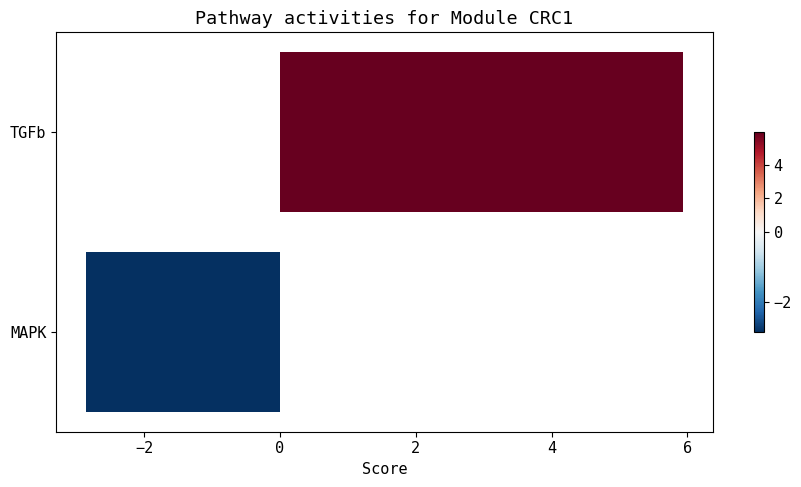

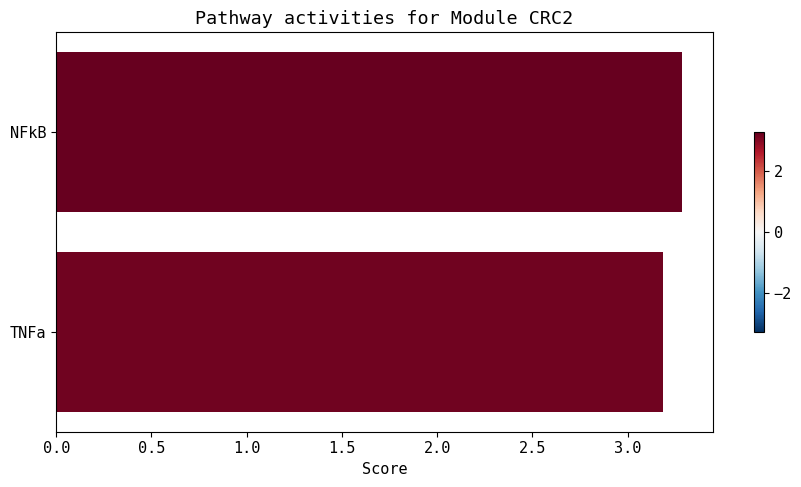

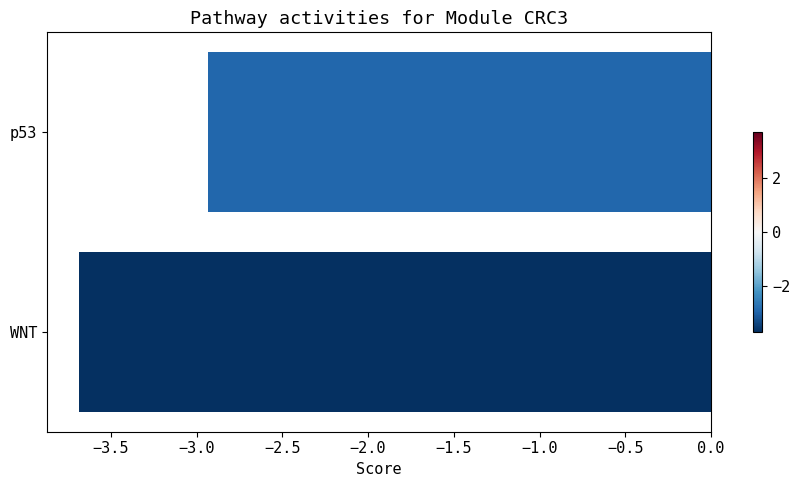

In [6]:
plot_pathway_activity(acts_p, padj_p, alpha=ALPHA)
plt.show()

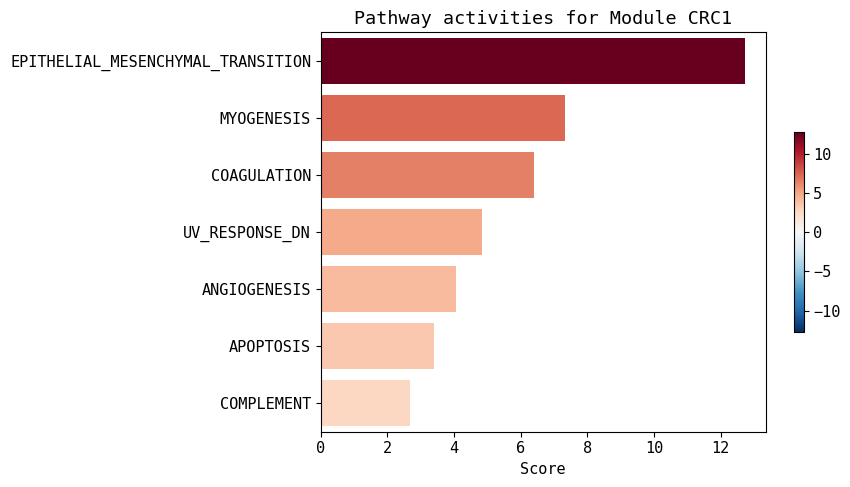

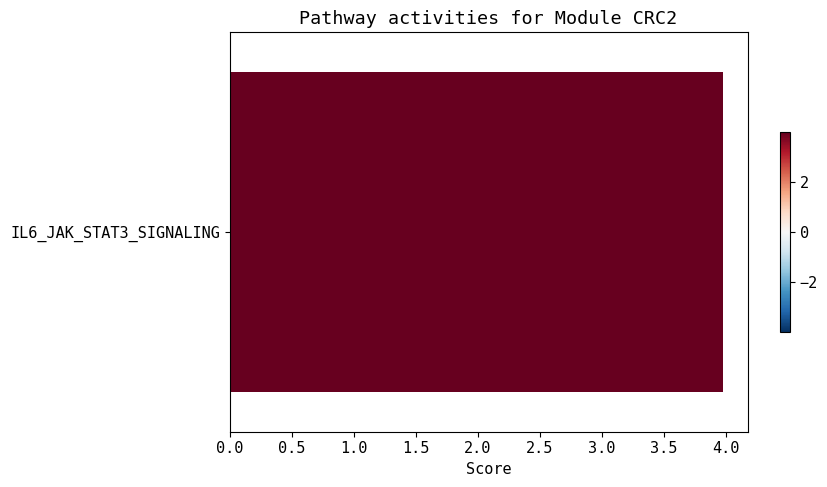

In [7]:
plot_pathway_activity(acts_h, padj_h, alpha=ALPHA)
plt.show()

## 3. Attention enrichments per microenvironment

`delta` is the microenvironment-specific part: the enrichment minus its mean over CRC1/2/3. Without it every panel would lead with the same global Plasma_cell suppression.

In [8]:
att = pd.read_csv(ATT_PATH)
att = att[(att.layer == ATT_LAYER) & att.ok & att.microenvironment.isin(CRC_MES)]
att = att.dropna(subset=["log2_enrichment"])

piv = att.pivot_table(index=["dst_type", "src_type"], columns="microenvironment",
                      values="log2_enrichment").reindex(columns=CRC_MES).dropna()
delta = piv.sub(piv.mean(axis=1), axis=0)

print(f"{len(piv)} (dst, src) pairs clear the n_dst threshold in all of {CRC_MES}")
print(f"enrichment range {piv.values.min():+.3f} .. {piv.values.max():+.3f}"
      f"  |  delta range {delta.values.min():+.3f} .. {delta.values.max():+.3f}")

81 (dst, src) pairs clear the n_dst threshold in all of ['CRC1', 'CRC2', 'CRC3']
enrichment range -1.214 .. +0.850  |  delta range -0.197 .. +0.224


## 4. Panels - pathways beside attention, per microenvironment

In [9]:
def panel(me):
    print("=" * 78)
    print(f"  {me}")
    print("=" * 78)

    sig = padj_p.loc[me] < ALPHA
    p_ord = acts_p.loc[me].reindex(acts_p.loc[me].abs().sort_values(ascending=False).index)
    print("\n  PROGENy (ULM t, * = FDR < %.2f)" % ALPHA)
    for k, v in p_ord.head(6).items():
        print(f"    {k:<12} {v:+7.2f} {'*' if sig[k] else ''}")

    hs = padj_h.loc[me] < ALPHA
    if hs.any():
        h_ord = acts_h.loc[me][hs].sort_values(key=np.abs, ascending=False)
        print("\n  Hallmark (FDR < %.2f)" % ALPHA)
        for k, v in h_ord.head(6).items():
            print(f"    {k[9:] if k.startswith('HALLMARK_') else k:<30} {v:+7.2f}")
    else:
        print("\n  Hallmark: nothing at FDR < %.2f" % ALPHA)

    d = delta[me].reindex(delta[me].abs().sort_values(ascending=False).index).head(TOP_ATT)
    print("\n  attention, layer %d   (enr = absolute, delta = specific to %s)" % (ATT_LAYER, me))
    print(f"    {'dst <- src':<30} {'enr':>7} {'delta':>7}")
    for (dst, src), dv in d.items():
        print(f"    {dst + ' <- ' + src:<30} {piv.loc[(dst, src), me]:+7.3f} {dv:+7.3f}")
    print()

for me in CRC_MES:
    panel(me)

  CRC1

  PROGENy (ULM t, * = FDR < 0.05)
    TGFb           +5.94 *
    MAPK           -2.85 *
    EGFR           -1.47 
    NFkB           -1.23 
    JAK-STAT       -0.75 
    Hypoxia        +0.73 

  Hallmark (FDR < 0.05)
    EPITHELIAL_MESENCHYMAL_TRANSITION  +12.72
    MYOGENESIS                       +7.34
    COAGULATION                      +6.40
    UV_RESPONSE_DN                   +4.84
    ANGIOGENESIS                     +4.05
    APOPTOSIS                        +3.39

  attention, layer 0   (enr = absolute, delta = specific to CRC1)
    dst <- src                         enr   delta
    Plasma_cell <- Epithelial       +0.463  -0.197
    Myeloid <- Plasma_cell          -0.489  +0.192
    Mast_cell <- Mast_cell          -0.294  -0.176
    Plasma_cell <- Myeloid          -0.096  -0.170
    Fibroblast <- Myeloid           -0.513  -0.168
    T_cell <- Plasma_cell           -0.491  +0.134
    Plasma_cell <- Endothelial      +0.243  -0.133
    Fibroblast <- Mast_cell         -0.

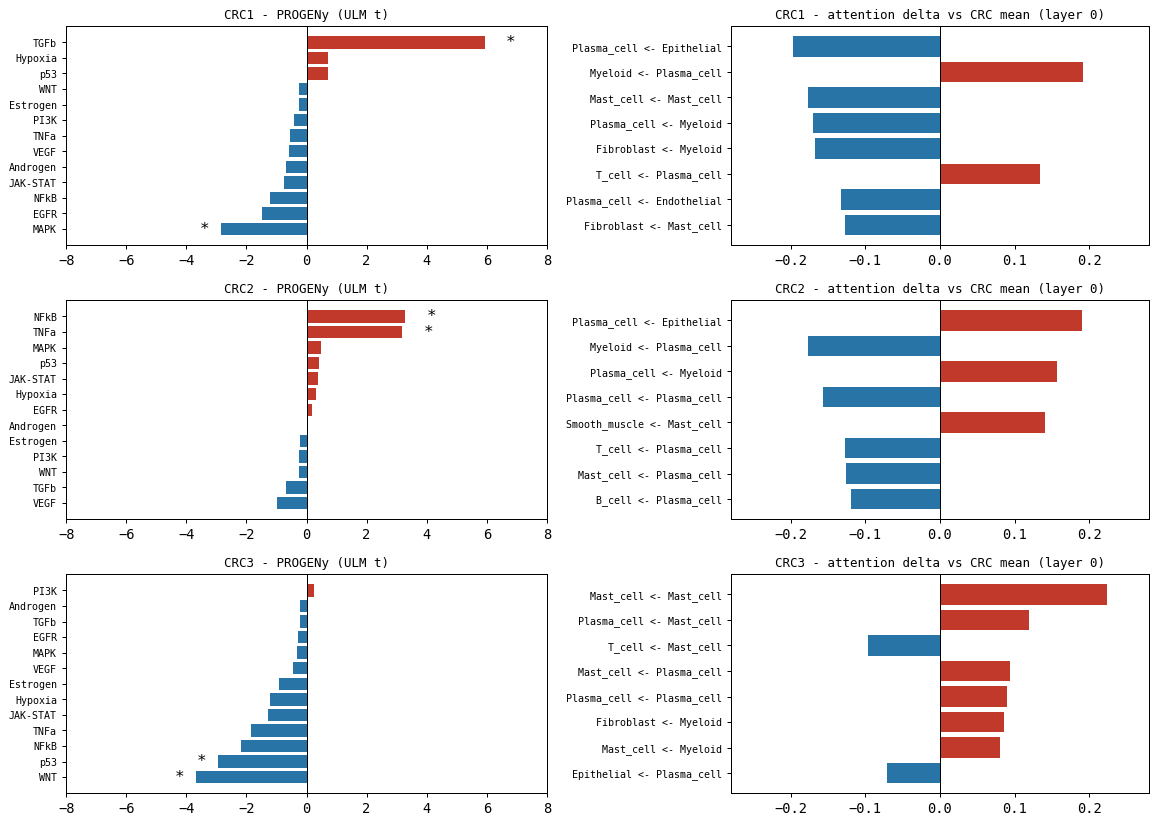

In [10]:
# side-by-side figure: pathway activity and attention deltas share a row per microenvironment
fig, axes = plt.subplots(len(CRC_MES), 2, figsize=(13, 3.1 * len(CRC_MES)),
                         gridspec_kw={"width_ratios": [1.15, 1]})
pmax = float(np.abs(acts_p.values).max())
dmax = float(np.abs(delta.values).max())

for r, me in enumerate(CRC_MES):
    ax = axes[r, 0]
    v = acts_p.loc[me].sort_values()
    cols = ["#c0392b" if x > 0 else "#2874a6" for x in v]
    ax.barh(range(len(v)), v.values, color=cols)
    for j, k in enumerate(v.index):
        if padj_p.loc[me, k] < ALPHA:
            ax.text(v[k] + np.sign(v[k]) * 0.12 * pmax, j, "*", va="center", fontsize=13)
    ax.set_yticks(range(len(v))); ax.set_yticklabels(v.index, fontsize=8)
    ax.axvline(0, color="k", lw=0.8); ax.set_xlim(-1.35 * pmax, 1.35 * pmax)
    ax.set_title(f"{me} - PROGENy (ULM t)", fontsize=10)

    ax = axes[r, 1]
    d = delta[me].reindex(delta[me].abs().sort_values(ascending=False).index).head(TOP_ATT)[::-1]
    lbl = [f"{a} <- {b}" for a, b in d.index]
    ax.barh(range(len(d)), d.values, color=["#c0392b" if x > 0 else "#2874a6" for x in d])
    ax.set_yticks(range(len(d))); ax.set_yticklabels(lbl, fontsize=8)
    ax.axvline(0, color="k", lw=0.8); ax.set_xlim(-1.25 * dmax, 1.25 * dmax)
    ax.set_title(f"{me} - attention delta vs CRC mean (layer {ATT_LAYER})", fontsize=10)

plt.tight_layout(); plt.show()

## 5. Save

In [11]:
acts_p.to_csv(f"{RES_DIR}/pathway_progeny_activity.csv")
padj_p.to_csv(f"{RES_DIR}/pathway_progeny_padj.csv")
acts_h.to_csv(f"{RES_DIR}/pathway_hallmark_activity.csv")
padj_h.to_csv(f"{RES_DIR}/pathway_hallmark_padj.csv")

joint = piv.copy()
for me in CRC_MES:
    joint[f"{me}_delta"] = delta[me]
joint.to_csv(f"{RES_DIR}/attention_enrichment_delta.csv")

summary = {
    "n_genes_in_modules": int(len(df)),
    "module_to_microenv": {str(k): v for k, v in MOD2ME.items()},
    "progeny_sig": {me: sorted(padj_p.columns[padj_p.loc[me] < ALPHA]) for me in acts_p.index},
    "hallmark_sig_n": {me: int((padj_h.loc[me] < ALPHA).sum()) for me in acts_h.index},
    "progeny_top": {me: acts_p.loc[me].abs().idxmax() for me in acts_p.index},
    "attention_layer": ATT_LAYER,
    "n_attention_pairs": int(len(piv)),
}
with open(f"{RES_DIR}/pathway_summary.json", "w") as fh:
    json.dump(summary, fh, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str))

{
  "n_genes_in_modules": 843,
  "module_to_microenv": {
    "1.0": "CRC1",
    "2.0": "CRC2",
    "3.0": "CRC3"
  },
  "progeny_sig": {
    "CRC1": [
      "MAPK",
      "TGFb"
    ],
    "CRC2": [
      "NFkB",
      "TNFa"
    ],
    "CRC3": [
      "WNT",
      "p53"
    ]
  },
  "hallmark_sig_n": {
    "CRC1": 7,
    "CRC2": 1,
    "CRC3": 0
  },
  "progeny_top": {
    "CRC1": "TGFb",
    "CRC2": "NFkB",
    "CRC3": "WNT"
  },
  "attention_layer": 0,
  "n_attention_pairs": 81
}
